In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [13]:
# Parameters
m = 1.0
c = 0.4
k = 4.0

# Initial conditions
x0 = 1.0
v0 = 0.0

# Time settings
t_start = 0.0
t_end = 10.0
N = 500
t_eval = np.linspace(t_start, t_end, N)
h = t_eval[1] - t_eval[0]

In [14]:
def system(t, y):
    x, v = y
    dxdt = v
    dvdt = -(c/m) * v - (k/m) * x
    return np.array([dxdt, dvdt])

In [15]:
reference = solve_ivp(
    fun=lambda t, y: system(t, y),
    t_span=(t_start, t_end),
    y0=[x0, v0],
    t_eval=t_eval,
    method='RK45'
)

t_ref = reference.t
x_ref = reference.y[0]
v_ref = reference.y[1]

In [16]:
def euler_solver(system, t_eval, y0):
    y = np.zeros((len(t_eval), len(y0)))
    y[0] = y0

    for i in range(len(t_eval) - 1):
        t = t_eval[i]
        h = t_eval[i + 1] - t_eval[i]
        y[i + 1] = y[i] + h * system(t, y[i])

    return y

In [17]:
def rk4_solver(system, t_eval, y0):
    y = np.zeros((len(t_eval), len(y0)))
    y[0] = y0

    for i in range(len(t_eval) - 1):
        t = t_eval[i]
        h = t_eval[i + 1] - t_eval[i]
        yi = y[i]

        k1 = system(t, yi)
        k2 = system(t + h/2, yi + h*k1/2)
        k3 = system(t + h/2, yi + h*k2/2)
        k4 = system(t + h, yi + h*k3)

        y[i + 1] = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return y

In [18]:
y0_vec = np.array([x0, v0])

euler_sol = euler_solver(system, t_eval, y0_vec)
rk4_sol = rk4_solver(system, t_eval, y0_vec)

x_euler = euler_sol[:, 0]
v_euler = euler_sol[:, 1]

x_rk4 = rk4_sol[:, 0]
v_rk4 = rk4_sol[:, 1]

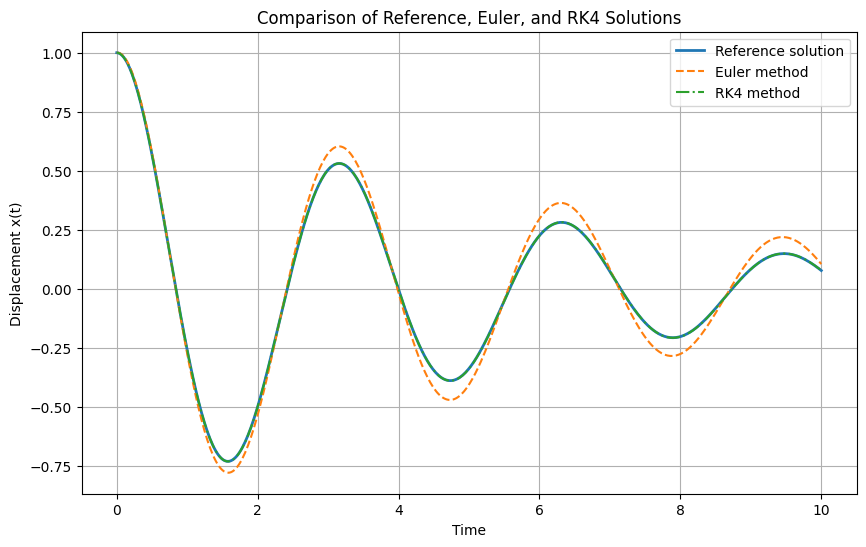

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref, x_ref, label='Reference solution', linewidth=2)
plt.plot(t_eval, x_euler, '--', label='Euler method')
plt.plot(t_eval, x_rk4, '-.', label='RK4 method')
plt.xlabel('Time')
plt.ylabel('Displacement x(t)')
plt.title('Comparison of Reference, Euler, and RK4 Solutions')
plt.legend()
plt.grid(True)
plt.show()

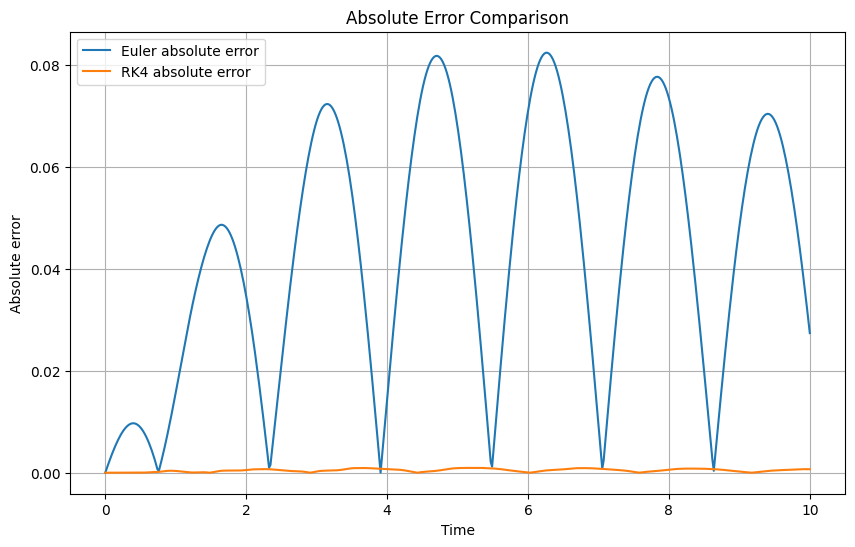

In [20]:
euler_error = np.abs(x_ref - x_euler)
rk4_error = np.abs(x_ref - x_rk4)

plt.figure(figsize=(10, 6))
plt.plot(t_eval, euler_error, label='Euler absolute error')
plt.plot(t_eval, rk4_error, label='RK4 absolute error')
plt.xlabel('Time')
plt.ylabel('Absolute error')
plt.title('Absolute Error Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
euler_mse = np.mean((x_ref - x_euler)**2)
rk4_mse = np.mean((x_ref - x_rk4)**2)

print("Euler MSE:", euler_mse)
print("RK4 MSE:", rk4_mse)

Euler MSE: 0.002505189667250845
RK4 MSE: 3.0350046662950486e-07


## Interpretation

Both Euler and RK4 can approximate the damped harmonic oscillator.

However, RK4 is much more accurate than Euler for the same time step size.  
The error plot and MSE values show that RK4 stays much closer to the reference solution.  
This suggests that higher-order numerical methods are more reliable for solving this system.